# Example 2: Double quantum dot initialization

Authors: C. Ventura-Meinersen and D. Fernandez-Fernandez

Below we import the necesary libraries for this example file:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import geodesiq as gq

# Double quantum dot model

In quantum processors based on quantum dots, one crutial bottleneck is the initilization of the spin qubits through spin-to-charge conversion. The effective model for this setup, in the basis $\{\ket{\uparrow\downarrow,\cdot},\ket{\uparrow,\uparrow},\ket{\uparrow,\downarrow},\ket{\downarrow,\uparrow},\ket{\downarrow,\downarrow}\}$, is given by
$$\hat{H}_{\text{DQD}} = \begin{pmatrix}
 \tilde{U}{-}\varepsilon(t) & 0 & -t_c & t_c & 0 \\
 0 & E_Z & \Delta\!E_X & -\Delta\!E_X & 0 \\
 -t_c & \Delta\!E_X & \Delta\!E_Z & 0 & \Delta\!E_X \\
 t_c & -\Delta\!E_X & 0 & -\Delta\!E_Z & -\Delta\!E_X \\
 0 & 0 & \Delta\!E_X & -\Delta\!E_X & -E_Z
\end{pmatrix},$$

where $t_c$ repesents the tunnel coupling, $E_a=E_{a,1}+E_{a,2}$ and $\Delta\!E_a=E_{a,1}-E_{a,2}$ are the total Zeeman energy and the Zeeman splitting difference (with $a=x,y,z$). Also, we define an effective Coulomb repulsion $\tilde{U}$ and the detuning $\varepsilon\in \mathbb{R}_{\geq 0}$ between the DQD chemical potentials.

The spin-to-charge conversion method requires the pulse shaping of the detuning $\varepsilon(t)$ from a far detuned position $\varepsilon(0)\gg |t_c|, |E_Z|$, where the ground state is given by two charges in one quantum dot (i.e., $\ket{\uparrow\downarrow, \cdot}$), to the symmetric point $\varepsilon(t_\text{f})=0$, where we have transferred one charge to the other dot $(2,0){\to}(1,1)$, where $(x,y)$ represents $x$ particles in one dot and $y$ particles in the other dot. Thereby, we initialize a computational state. Due to a finite spin-flipping term $\Delta\!E_X$, which causes a small gap between the ground and first excited state.

Below we setup the problem:

In [ ]:
def dqd_hamiltonian(eps, U, tc, Ez, dEz, dEx):
    ham = np.array([[U - eps, 0, -tc, tc, 0], [0, Ez, dEx, -dEx, 0], [-tc, dEx, dEz, 0, dEx], [tc, -dEx, 0, -dEz, -dEx],
                    [0, 0, dEx, -dEx, -Ez]])
    return ham


dqd_model = gq.ControlModel(dqd_hamiltonian)

# ----- Set system and control parameters -----
alpha, beta = 2, 2

U, tc, Ez, dEz, dEx = 10, 1, .9, .1, .01
eps0, epsf = 15, 0

dqd_model.set_parameters(U=U, tc=tc, Ez=Ez, dEz=dEz, dEx=dEx)
dqd_model.set_control(control_name='eps', pulse_initial=eps0, pulse_final=epsf, initial_state=0, alpha=alpha, beta=beta)

Plotting the eigenvalues shows the small anti-crossing between the ground state and the first excited state, which may cause nonadiabatic transitions

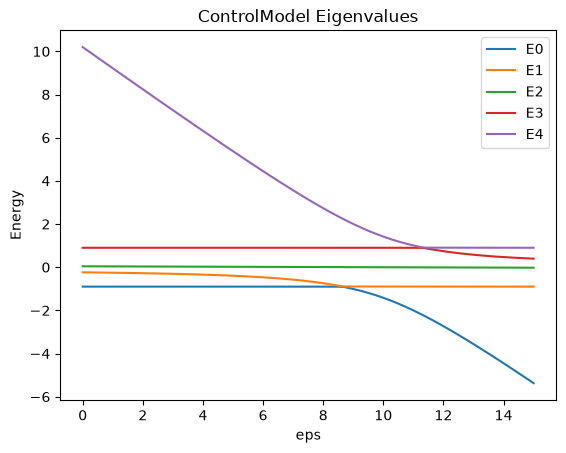

In [4]:
dqd_model.plot_eigenvalues();

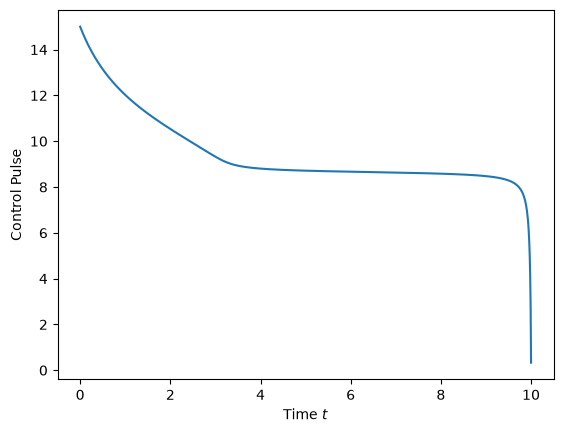

In [5]:
# ----- Solve for optimal pulse -----
dqd_model.solve_problem(pulse_accuracy=int(1000))

pulse = dqd_model.synthesize_pulse(duration=10)
pulse.plot_pulse();

# Time dynamics

Here we can ananlyze again the resulting state transfer fidelities for the geometric fast-QUAD and the FAQUAD:

In [6]:
def fidelity_vs_time(durations, model, alpha=2, beta=2):
    model.set_control(alpha=alpha, beta=beta)
    model.solve_problem(pulse_accuracy=int(1000))

    fidelities = []
    for duration in durations:
        dynamics = gq.Dynamics(duration=duration, model=model)
        fidelities.append(dynamics.state_fidelity())

    return np.array(fidelities)

In [7]:
durations = np.linspace(0, 1000, 200)

# Takes roughly between 1 and 2 minutes to run locally
fidelities_geometric = fidelity_vs_time(durations, dqd_model, alpha=2, beta=2)
fidelities_faquad = fidelity_vs_time(durations, dqd_model, alpha=4, beta=2)

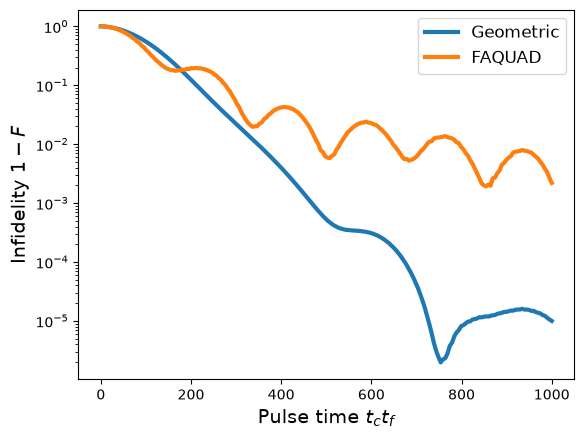

In [8]:
plt.plot(durations, 1 - fidelities_geometric, label='Geometric', lw=3)
plt.plot(durations, 1 - fidelities_faquad, label='FAQUAD', lw=3)
plt.yscale('log')
plt.ylabel('Infidelity $1-F$', fontsize=14)
plt.xlabel('Pulse time $t_c t_f$', fontsize=14)
plt.legend(fontsize=12)
plt.show();

# $(\alpha,\beta)$ fidelity sweep: pure adiabatic evolution


The choice of $\alpha$ and $\beta$ (and their diabatic counterparts) allows for smooth deformation of existing adiabatic pulses. Therefore, for any given parameter setting it might be helpful to study the set of possible adiabatic pulses. 

As a single pulse can always be rescaled for all possible total pulse times, we can efficiently optimize the search by using the `joblib` Python package

In [9]:
# joblib is an additional Python package for parallel computing
import itertools

from joblib import Parallel, delayed

In [10]:
def optimal_fidelity_time_map(durations, model, alphas, betas, n_jobs=-1):
    """
    Function that computes the fidelity map for a range of alpha and beta values over a range of durations.
    The function relies on the definition of fidelity_vs_time() from above.
    """
    results = Parallel(n_jobs=n_jobs)(
        delayed(fidelity_vs_time)(durations, model, alpha=alpha, beta=beta) for alpha, beta in
        itertools.product(alphas, betas))

    fidelities = np.array(results).reshape(len(alphas), len(betas), len(durations))

    max_fidelities = np.max(fidelities, axis=2)
    best_times = durations[np.argmax(fidelities, axis=2)]

    return max_fidelities, best_times

In [10]:
durations_2d = np.linspace(0, 1000, 100)

alphas = np.linspace(0, 4, 7)
betas = np.linspace(0, 4, 7)

optimal_fidelities, best_times = optimal_fidelity_time_map(durations_2d, dqd_model, alphas, betas)

Below we plot the resulting heatmaps for the optimal fidelity and the corresponding total pulse time for a set of possible ($\alpha,\beta$)

In [ ]:
fontsizes = 14
fontsize_label = 16
colorbar_loc = 'top'
cmap_coloring_fid = 'PuBu_r'
extent = [min(alphas), max(alphas), min(betas), max(betas)]

fig, axs = plt.subplots(1, 2, figsize=(7, 4), sharey=True)

# --- Left Plot: Optimal Fidelity ---
fidelity_error = np.log10(1 - optimal_fidelities.T)

im0 = axs[0].imshow(fidelity_error, origin='lower', aspect='auto', interpolation='none', extent=extent,
                    cmap=cmap_coloring_fid)
axs[0].set_xlabel(r'$\alpha$', fontsize=fontsize_label)
axs[0].set_ylabel(r'$\beta$', fontsize=fontsize_label)
axs[0].tick_params(labelsize=fontsizes)

cbar0 = plt.colorbar(im0, ax=axs[0], location=colorbar_loc, pad=0.05)
cbar0.set_label(r'$\log_{10}(1 - \tilde{\mathcal{F}})$', size=fontsize_label)
cbar0.ax.tick_params(labelsize=fontsizes)

# --- Right Plot: Best Times ---
im1 = axs[1].imshow(best_times.T, origin='lower', aspect='auto', interpolation='none', extent=extent, cmap='inferno_r')
axs[1].set_xlabel(r'$\alpha$', fontsize=fontsize_label)
axs[1].tick_params(labelsize=fontsizes)

cbar1 = plt.colorbar(im1, ax=axs[1], location=colorbar_loc, pad=0.05)
cbar1.set_label(r'$\tilde{t}_\text{f}\,t_c$', size=fontsize_label)
cbar1.ax.tick_params(labelsize=fontsizes)

plt.tight_layout()
plt.show();

# Combined plotting (first run both optimizations individually)

This is the code to obtain the plot from the accompanying article.

In [ ]:
fontsizes = 14
fontsize_label = 16
colorbar_loc = 'top'
cmap_coloring_fid = 'PuBu_r'
extent = [min(alphas), max(alphas), min(betas), max(betas)]

fig, axs = plt.subplots(1, 3, figsize=(11, 4))

axs[0].plot(durations, 1 - fidelities_geometric, label='Geometric', lw=3)
axs[0].plot(durations, 1 - fidelities_faquad, label='FAQUAD', lw=3)
axs[0].set_yscale('log')
axs[0].set_ylabel(r'Infidelity $1-\mathcal{F}$', fontsize=fontsize_label)
axs[0].set_xlabel('Pulse time $t_c t_f$', fontsize=fontsize_label)
axs[0].tick_params(labelsize=fontsizes)
axs[0].legend(fontsize=12)

infidelity_opt = np.log10(1 - optimal_fidelities.T)

im1 = axs[1].imshow(infidelity_opt, origin='lower', aspect='auto', interpolation='none', extent=extent,
                    cmap=cmap_coloring_fid)
axs[1].set_xlabel(r'$\alpha$', fontsize=fontsize_label)
axs[1].set_ylabel(r'$\beta$', fontsize=fontsize_label)
axs[1].tick_params(labelsize=fontsizes)

axs[1].scatter(2, 2, s=120, label='Geometric', edgecolor='black', linewidths=2)
axs[1].scatter(3.8, 2, s=120, label='FAQUAD', edgecolor='black', linewidths=2)

cbar1 = plt.colorbar(im1, ax=axs[1], location=colorbar_loc, pad=0.05)
cbar1.set_label(r'$\log_{10}(1 - \tilde{\mathcal{F}})$', size=fontsize_label)
cbar1.ax.tick_params(labelsize=fontsizes)

im2 = axs[2].imshow(best_times.T, origin='lower', aspect='auto', interpolation='none', extent=extent, cmap='inferno_r')
axs[2].set_xlabel(r'$\alpha$', fontsize=fontsize_label)
axs[2].set_ylabel(r'$\beta$', fontsize=fontsize_label)
axs[2].tick_params(labelsize=fontsizes)

cbar2 = plt.colorbar(im2, ax=axs[2], location=colorbar_loc, pad=0.05)
cbar2.set_label(r'$\tilde{t}_\text{f}\,t_c$', size=fontsize_label)
cbar2.ax.tick_params(labelsize=fontsizes)

plt.tight_layout()
plt.show();

About

In [12]:
gq.about()

--------------------------------------------------
geodesiq Information
--------------------------------------------------
geodesiq version: 0.1.0
Python version:    3.10.16 (cpython)
Operating System:  Linux (5.15.0-157-generic, x86_64)

Core Dependencies:
  numpy          : 2.2.6
  scipy          : 1.15.3
--------------------------------------------------


Please cite geodesiq in your publication:
Your Citation Information Here
